# Botnet Detection & Classification using Machine Learning

This notebook implements a **multi-class classification** pipeline that can:
1. **Detect** whether network traffic is malicious or benign
2. **Classify** the specific attack type (SYN Flood, LDAP Reflection, UDP Flood)

**Dataset**: CIC-DDoS2019 (Parquet format)  
**Model**: Random Forest Classifier  
**Classes**: `Benign` | `Syn` | `LDAP` | `UDP`

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import os
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully.')

Libraries imported successfully.


## 1. Dataset Loading & Label Normalization

We load all available training and testing files (SYN, LDAP, and UDP) and merge them.  
Labels are normalized since the dataset uses inconsistent names across different files.

> **Strategy**: We merge all files and perform a stratified split to ensure the model sees a balanced distribution of behavioral features that might be missing or zero-scaled in individual author-provided test files.

In [15]:
def normalize_label(label):
    label = str(label).strip().lower()
    if 'benign' in label:
        return 'Benign'
    elif 'syn' in label:
        return 'Syn'
    elif 'ldap' in label:
        return 'LDAP'
    elif 'udp' in label:
        return 'UDP'
    else:
        return 'Other'


# Load ALL files
all_files = [
    'Syn-training.parquet', 'Syn-testing.parquet',
    'LDAP-training.parquet', 'LDAP-testing.parquet',
    'UDP-training.parquet', 'UDP-testing.parquet'
]

frames = []
for f in all_files:
    path = os.path.join('data', f)
    if os.path.exists(path):
        print(f'  Loading {f}...')
        df = pd.read_parquet(path)
        df['Label'] = df['Label'].apply(normalize_label)
        frames.append(df)

df_all = pd.concat(frames, ignore_index=True)

# Keep only target classes
TARGET_CLASSES = ['Benign', 'Syn', 'LDAP', 'UDP']
df_all = df_all[df_all['Label'].isin(TARGET_CLASSES)].reset_index(drop=True)

print(f'\nTotal samples: {len(df_all)}')
print(df_all['Label'].value_counts())

  Loading Syn-training.parquet...
  Loading Syn-testing.parquet...
  Loading LDAP-training.parquet...
  Loading LDAP-testing.parquet...
  Loading UDP-training.parquet...
  Loading UDP-testing.parquet...

Total samples: 110630
Label
Syn       43835
Benign    38259
UDP       25212
LDAP       3324
Name: count, dtype: int64


## 2. Feature Selection

We use 22 behavioral features that capture volume, timing, protocol state, and packet sizes.

In [16]:
SELECTED_FEATURES = [
    'Total Fwd Packets', 'Total Backward Packets',
    'Fwd Packets Length Total', 'Bwd Packets Length Total',
    'Flow Duration', 'Flow IAT Mean', 'Flow IAT Std',
    'Fwd IAT Total', 'Bwd IAT Total',
    'Flow Bytes/s', 'Flow Packets/s', 'Fwd Packets/s', 'Bwd Packets/s',
    'Packet Length Mean', 'Packet Length Std', 'Avg Packet Size',
    'SYN Flag Count', 'ACK Flag Count', 'RST Flag Count',
    'Protocol', 'Init Fwd Win Bytes', 'Down/Up Ratio',
]

available = [f for f in SELECTED_FEATURES if f in df_all.columns]
print(f'Using {len(available)} features for training.')

Using 22 features for training.


## 3. Preprocessing

Handle infinities, encode the 4 classes, and perform a stratified 80/20 split.

In [17]:
X = df_all[available].copy()
y_raw = df_all['Label']

X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)

le = LabelEncoder()
le.fit(TARGET_CLASSES)
y = le.transform(y_raw)
print(f'Label Mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\nTraining: {X_train_scaled.shape[0]} samples')
print(f'Testing:  {X_test_scaled.shape[0]} samples')

Label Mapping: {np.str_('Benign'): np.int64(0), np.str_('LDAP'): np.int64(1), np.str_('Syn'): np.int64(2), np.str_('UDP'): np.int64(3)}

Training: 88504 samples
Testing:  22126 samples


## 4. Model Training

In [18]:
model = RandomForestClassifier(n_estimators=200, max_depth=30, random_state=42, n_jobs=-1)
print('[*] Training Random Forest for 4-class classification...')
model.fit(X_train_scaled, y_train)
print('[+] Training complete.')

[*] Training Random Forest for 4-class classification...
[+] Training complete.


## 5. Evaluation

In [19]:
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f'Overall Accuracy: {accuracy:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Overall Accuracy: 0.9987

Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      7652
        LDAP       1.00      1.00      1.00       665
         Syn       1.00      1.00      1.00      8767
         UDP       1.00      1.00      1.00      5042

    accuracy                           1.00     22126
   macro avg       1.00      1.00      1.00     22126
weighted avg       1.00      1.00      1.00     22126



## 6. Visualization

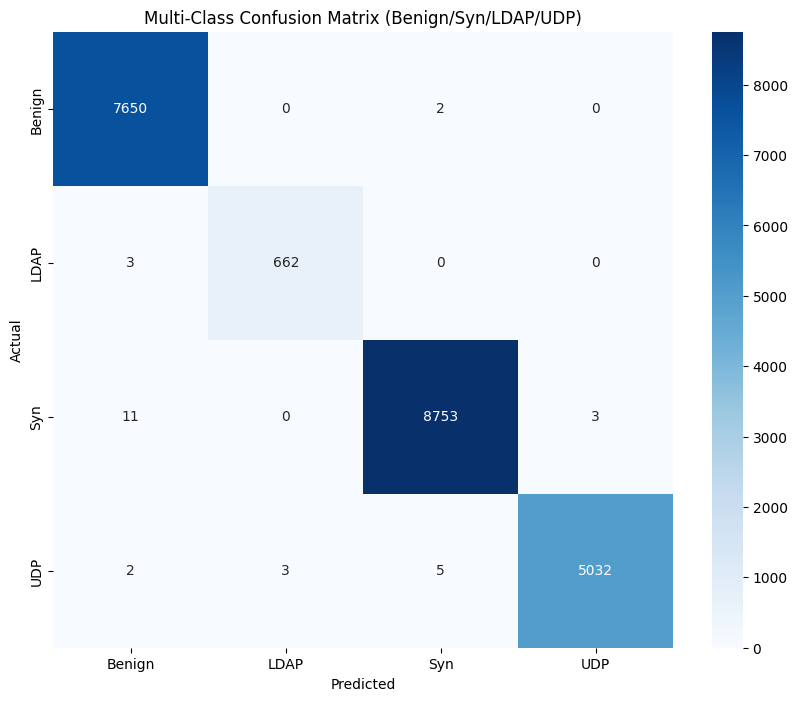

In [20]:
os.makedirs('results', exist_ok=True)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Multi-Class Confusion Matrix (Benign/Syn/LDAP/UDP)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('results/confusion_matrix.png')
plt.show()

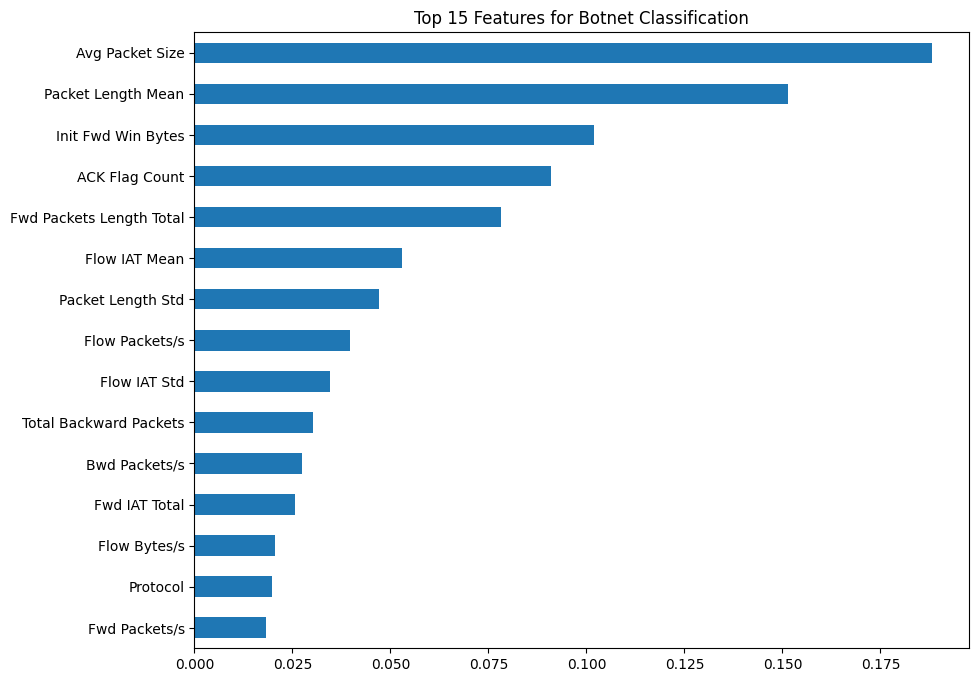

In [21]:
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=available).sort_values(ascending=False)
plt.figure(figsize=(10, 8))
feat_imp.head(15).plot(kind='barh').invert_yaxis()
plt.title('Top 15 Features for Botnet Classification')
plt.savefig('results/feature_importance.png')
plt.show()

In [22]:
import joblib
artifact = {'model': model, 'scaler': scaler, 'label_encoder': le, 'features': available}
joblib.dump(artifact, 'results/botnet_classifier.joblib')
print('[+] Model saved successfully.')

[+] Model saved successfully.
